In [1]:
!pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.7 MB/s eta 0:00:00


In [2]:
# Download 10 sample TTF fonts for testing
!wget -O Roboto-Regular.ttf "https://github.com/google/fonts/raw/main/apache/roboto/Roboto-Regular.ttf"
!wget -O OpenSans-Regular.ttf "https://github.com/google/fonts/raw/main/apache/opensans/OpenSans-Regular.ttf"
!wget -O Lato-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/lato/Lato-Regular.ttf"
!wget -O Montserrat-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/montserrat/Montserrat-Regular.ttf"
!wget -O SourceSansPro-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/sourcesanspro/SourceSansPro-Regular.ttf"
!wget -O Poppins-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/poppins/Poppins-Regular.ttf"
!wget -O Nunito-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/nunito/Nunito-Regular.ttf"
!wget -O Ubuntu-Regular.ttf "https://github.com/google/fonts/raw/main/ufl/ubuntu/Ubuntu-Regular.ttf"
!wget -O Inter-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/inter/Inter-Regular.ttf"
!wget -O Raleway-Regular.ttf "https://github.com/google/fonts/raw/main/ofl/raleway/Raleway-Regular.ttf"

# Verify downloads
!ls -la *.ttf

--2025-09-28 05:39:45--  https://github.com/google/fonts/raw/main/apache/roboto/Roboto-Regular.ttf
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-09-28 05:39:45 ERROR 404: Not Found.

--2025-09-28 05:39:45--  https://github.com/google/fonts/raw/main/apache/opensans/OpenSans-Regular.ttf
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-09-28 05:39:45 ERROR 404: Not Found.

--2025-09-28 05:39:45--  https://github.com/google/fonts/raw/main/ofl/lato/Lato-Regular.ttf
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google/fonts/main/ofl/lato/Lato-Regular.ttf [following]
--

In [3]:
# Upgrade/install bitsandbytes
!pip install -U bitsandbytes

# Also update transformers and accelerate
!pip install -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 17.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 68.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.56.1
    Uninstalling transformers-4.56.1:
      Successfully uninstalled transformers-4.56.1


In [ ]:
# @title ## Step 0.5: Memory-Efficient Model Loading
# @markdown Load LLaMA and Stable Diffusion with quantization / memory optimizations.

# --- LLaMA 3.1-8B (QLoRA / 4-bit quantization)
!pip install -q transformers accelerate bitsandbytes

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

from huggingface_hub import login

login(token="")

llama_model_name = "meta-llama/Llama-3.1-8B-Instruct"

print("⏳ Loading LLaMA 3.1-8B with 4-bit quantization...")
tokenizer = AutoTokenizer.from_pretrained(llama_model_name)

# Load in 4-bit mode using bitsandbytes (much lower VRAM usage)
llama_model = AutoModelForCausalLM.from_pretrained(
    llama_model_name,
    device_map="auto",  # automatically assigns layers to GPU/CPU
    load_in_4bit=True,  # 4-bit quantization
    torch_dtype=torch.float16,
    offload_folder="offload_llama",  # optional folder for CPU offloading
)

print("✅ LLaMA loaded in memory-efficient 4-bit mode.")

# --- Stable Diffusion (SD-3 Medium) with low VRAM
!pip install -q diffusers transformers accelerate safetensors

from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

sd_model_name = "runwayml/stable-diffusion-v1-5"  # you can replace with another runwayml variant

print("⏳ Loading RunwayML Stable Diffusion with low VRAM optimizations...")

# Load pipeline in half-precision for VRAM savings
sd_pipe = StableDiffusionPipeline.from_pretrained(
    sd_model_name,
    torch_dtype=torch.float16,  # half precision
    safety_checker=None,        # optional: disable safety checker to save VRAM
).to("cuda")

# Use memory-efficient scheduler
sd_pipe.scheduler = DPMSolverMultistepScheduler.from_config(sd_pipe.scheduler.config)

# Enable attention slicing to reduce VRAM usage
sd_pipe.enable_attention_slicing()

print("✅ RunwayML Stable Diffusion loaded with low VRAM optimizations.")

# Example prompt test (optional)
# prompt = "A luxury moisturizer product, soft lighting, elegant background"
# image = sd_pipe(prompt).images[0]
# image.show()


⏳ Loading LLaMA 3.1-8B with 4-bit quantization...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

✅ Setup complete.


Saving moisturiser.jpg to moisturiser (1).jpg
✅ Image 'moisturiser (1).jpg' uploaded successfully.
⏳ Removing background...
✅ Background removed successfully!


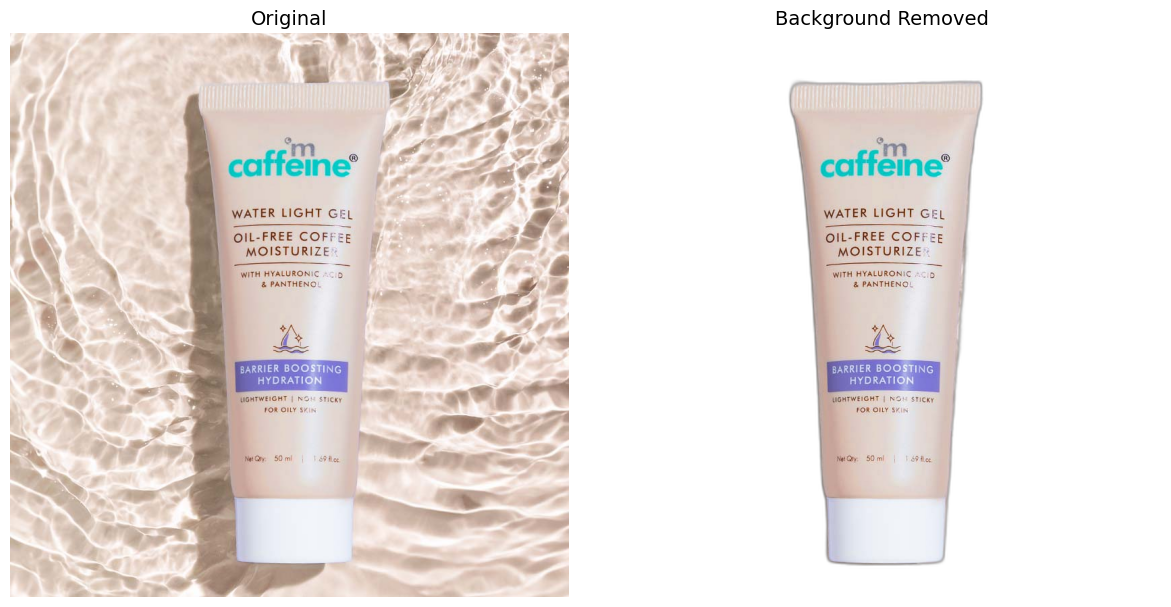

✅ Enhanced Orchestrator chain created.
✅ All agents defined with category-based background intelligence.
🔍 Detected Product Category: LUXURY
🧠 Invoking Enhanced Orchestrator...

❌ Error during enhanced workflow: 402 Client Error: Payment Required for url: https://router.huggingface.co/cerebras/v1/chat/completions (Request ID: Root=1-68d8026c-0c5c8755215b82e4021c8b69;9d442838-688c-418e-ac97-19c4985a3e18)

You have exceeded your monthly included credits for Inference Providers. Subscribe to PRO to get 20x more monthly included credits.
Please check your API key and try again.


In [ ]:
# -*- coding: utf-8 -*-
"""
# 🤖 Enhanced Generative Ad PoC: LangChain Edition

This enhanced notebook implements intelligent multi-agent workflow with significant quality improvements:
- Smart product categorization and style detewction
- Enhanced prompt engineering with visual harmony principles
- Improved typography with dynamic sizing and positioning
- Better composition rules and shadow effectsw
- More sophisticated background generation prompts

**Workflow Steps:**
1.  **User Input:** Upload a product image and write a brief description.
2.  **Product Prep:** The background is automatically removed from your image.
3.  **Enhanced LangChain Components:** Improved agents with better prompting and logic.
4.  **Workflow Execution:** Generate professional-grade advertisements with visual harmony.
"""

# @title ## Step 0: Setup & API Keys

!pip install -qU langchain langchain-huggingface pillow rembg huggingface_hub matplotlib

import os
import json
from PIL import Image, ImageDraw, ImageFont, ImageFilter, ImageEnhance
from io import BytesIO
import matplotlib.pyplot as plt
from google.colab import files
from rembg import remove
from getpass import getpass
import re
import random

# LangChain components
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint



HF_API_KEY = ""
os.environ['HUGGINGFACEHUB_API_TOKEN'] = HF_API_KEY

print("✅ Setup complete.")

# @title ## Step 1: User Input (Your Product & Goal)

product_description = "Luxury hydrating moisturizer – the ultimate beauty essential for radiant skin." # @param {type:"string"}

uploaded_file = files.upload()
input_product_image = None

if uploaded_file:
    file_name = next(iter(uploaded_file))
    print(f"✅ Image '{file_name}' uploaded successfully.")
    input_product_image = Image.open(BytesIO(uploaded_file[file_name]))
else:
    print("🚨 Please upload an image to continue.")

# @title ## Step 2: Prepare Product Image (Background Removal)

product_image_no_bg = None
if input_product_image:
    print("⏳ Removing background...")
    try:
        # Enhanced background removal with better quality
        buffer = BytesIO()
        # Enhance image quality before background removal
        enhanced_img = ImageEnhance.Sharpness(input_product_image).enhance(1.2)
        enhanced_img.save(buffer, format="PNG")
        image_bytes = buffer.getvalue()

        output_bytes = remove(image_bytes)
        product_image_no_bg = Image.open(BytesIO(output_bytes))

        print("✅ Background removed successfully!")

        # Display a side-by-side comparison
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(input_product_image)
        axes[0].set_title("Original", fontsize=14)
        axes[0].axis("off")

        axes[1].imshow(product_image_no_bg)
        axes[1].set_title("Background Removed", fontsize=14)
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ Could not remove background: {e}")
else:
    print("Skipping background removal as no image was uploaded.")


# @title ## Step 3: Enhanced LangChain Components

# Enhanced product categorization function
def analyze_product_category(description):
    """Intelligently categorize products for better styling"""
    description_lower = description.lower()

    categories = {
        'luxury': ['luxury', 'premium', 'high-end', 'exclusive', 'chanel', 'gucci', 'louis vuitton', 'rolex'],
        'tech': ['phone', 'laptop', 'gadget', 'device', 'smart', 'electronic', 'digital', 'wireless'],
        'beauty': ['perfume', 'cosmetic', 'makeup', 'skincare', 'fragrance', 'beauty', 'lipstick'],
        'fashion': ['clothing', 'shirt', 'dress', 'shoes', 'accessory', 'jewelry', 'watch', 'bag'],
        'food': ['food', 'drink', 'beverage', 'snack', 'restaurant', 'cuisine', 'coffee', 'wine'],
        'automotive': ['car', 'vehicle', 'automotive', 'bike', 'motorcycle', 'truck'],
        'fitness': ['fitness', 'gym', 'workout', 'sports', 'athletic', 'exercise', 'health']
    }

    for category, keywords in categories.items():
        if any(keyword in description_lower for keyword in keywords):
            return category

    return 'general'

# --- 🧠 Enhanced Orchestrator Agent Components ---

class SceneArtistInstructions(BaseModel):
    prompt: str = Field(description="A highly detailed, professional photography prompt for creating a premium background that complements the product. The background SHOULD NOT CONTAIN the product itself. Must specify lighting, mood, and composition details. The background should be such that it doesnt clash with the overlayed product and text.")

from typing import Literal

class TypographerInstructions(BaseModel):
    headline: str = Field(description="The main headline text for the ad. Character limit 20")
    tagline: str = Field(description="The secondary text or tagline. Character limit 30")
    font_prompt: Literal[
        "Lato-Regular.ttf",
        "Poppins-Bold.ttf",
        "Poppins-Regular.ttf",
        "Ubuntu-Regular.ttf"
    ] = Field(description="Choose one of the available fonts in the environment.")
    headline_size: int = Field(description="Font size for the headline in px, between 40 and 120.")
    tagline_size: int = Field(description="Font size for the tagline in px, between 20 and 60.")
    color_prompt: str = Field(description="Hex code for the text color, e.g. '#857540'")

class CreativeBrief(BaseModel):
    campaign_concept: str = Field(description="A short, catchy concept for the ad campaign.")
    overall_mood: str = Field(description="Keywords describing the ad's feeling.")
    layout_archetype: str = Field(description="The chosen layout archetype, e.g., 'Hero_Center_Text_Bottom'.")
    scene_artist_instructions: SceneArtistInstructions
    typographer_instructions: TypographerInstructions
    compositor_instructions: str = Field(description="A hint for how to place the product.")

# Enhanced parser and prompt
parser = JsonOutputParser(pydantic_object=CreativeBrief)

# Enhanced parser and prompt with category-specific intelligence but simpler structure
parser = JsonOutputParser(pydantic_object=CreativeBrief)

enhanced_prompt_template = ChatPromptTemplate.from_template(
    """You are an expert creative director AI for a high-end advertising agency. Your purpose is to conceptualize and generate a complete creative brief for a professional product advertisement.

Your primary goal is **visual harmony**. You must design a background scene that makes the user's provided product look like it truly belongs there. The final image should be a coherent, professional advertisement frame.

**Product Analysis:**
Product Description: `{product_description}`
Detected Category: `{product_category}`

**Category-Specific Background Guidelines:**

**LUXURY** (perfume, jewelry, watches):
- Use marble textures, silk fabrics, dramatic studio lighting, minimalist elegance
- Think high-end magazine advertisements with sophisticated materials

**TECH** (electronics, gadgets):
- Clean geometric patterns, gradient lighting, modern surfaces, futuristic elements
- Professional tech product photography style

**BEAUTY** (cosmetics, skincare):
- Soft textures, natural elements like flowers or water, dreamy atmospheres
- Elegant beauty photography with romantic lighting

**FASHION** (clothing, accessories):
- Lifestyle settings, interesting textures, dynamic compositions
- Fashion photography with trendy, stylish backgrounds

**FOOD/BEVERAGE**:
- Warm lighting, appetizing environments
- Restaurant tables or kitchen settings with premium feel

**AUTOMOTIVE**:
- Roads, urban environments, dramatic landscapes
- Professional automotive photography settings

For scene_artist_instructions.prompt, create a detailed background that:
- Matches the product category above
- Uses professional photography lighting
- Creates depth and visual interest
- Complements rather than competes with the product
- Avoids any text, logos, or distracting elements

**Analyze the user's product description below to infer its key visual characteristics:**
- **Product:** `{product_description}`
- **Inferable traits:** Consider the product's likely materials, style, and color palette.

You MUST choose one layout archetype from this list: `{layout_archetypes}`

You MUST:
- Return only JSON (no explanations, no markdown, no prose, no comments).
- Do not include ```json or any extra text.
- Ensure values match the expected types.

{format_instructions}
"""
)

# Enhanced LLM setup with better parameters
llm_endpoint = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    temperature=0.8,  # Increased creativity
    max_new_tokens=1500,  # More tokens for detailed responses
    top_p=0.9,  # Better token selection
)
llm = ChatHuggingFace(llm=llm_endpoint)

orchestrator_chain = enhanced_prompt_template | llm | parser
print("✅ Enhanced Orchestrator chain created.")

# --- 🎨 Enhanced Scene Artist Agent ---
from huggingface_hub import InferenceClient
client = InferenceClient(
    model="stabilityai/stable-diffusion-3-medium",
    token=HF_API_KEY   # pass directly
)

def generate_enhanced_scene(prompt: str, product_category: str) -> Image.Image:
    """Enhanced scene generation with category-specific improvements"""
    #client = InferenceClient()

    # Category-specific enhancement prompts
    '''category_enhancers = {
    'luxury': ", professional studio lighting, premium materials, award-winning commercial photography, 8K resolution, include a subtle pedestal or platform for the product",
    'tech': ", clean modern aesthetic, high-tech atmosphere, dramatic lighting, futuristic, commercial grade, include a platform for product display",
    'beauty': ", soft romantic lighting, dreamy atmosphere, high-end cosmetics photography, ethereal mood, product pedestal or tray",
    'fashion': ", fashion photography, editorial style, dynamic composition, trendy aesthetic, include a stage or platform for the product",
    'automotive': ", dramatic automotive photography, powerful lighting, cinematic composition, product on platform if applicable",
    'general': ", professional commercial photography, high-end advertising style, premium quality, include a platform for product"
    }'''

    category_enhancers = {
    'luxury': ", professional studio lighting, premium materials, award-winning commercial photography, 8K resolution",
    'tech': ", clean modern aesthetic, high-tech atmosphere, dramatic lighting, futuristic, commercial grade",
    'beauty': ", soft romantic lighting, dreamy atmosphere, high-end cosmetics photography, ethereal mood",
    'fashion': ", fashion photography, editorial style, dynamic composition, trendy aesthetic",
    'automotive': ", dramatic automotive photography, powerful lighting, cinematic composition",
    'general': ", professional commercial photography, high-end advertising style, premium quality"
}

    enhanced_prompt = prompt + category_enhancers.get(product_category, category_enhancers['general'])

    # Enhanced negative prompt for better quality
    enhanced_negative_prompt = ("text, letters, watermark, signature, blurry, low quality, "
                              "amateur photography, poor lighting, cluttered, distracting elements, "
                              "oversaturated, undersaturated, artifacts")

    result = client.text_to_image(
        model="stabilityai/stable-diffusion-3-medium",
        prompt=enhanced_prompt,
        negative_prompt=enhanced_negative_prompt,
        width=1024,  # Higher resolution
        height=1024,
        guidance_scale=7.5,  # Better adherence to prompt
    )

    if isinstance(result, bytes):
        return Image.open(BytesIO(result))
    elif isinstance(result, Image.Image):
        return result
    else:
        raise TypeError(f"Unexpected return type: {type(result)}")

# --- ✍️ Original Typographer & 🎨 Compositor (Programmatic Agents) ---
def render_typography(instructions, width):
    headline_text = instructions.get("headline", "Headline")
    tagline_text = instructions.get("tagline", "Tagline")

    # --- Font sizes ---
    headline_size = instructions.get("headline_size", 80)
    tagline_size = instructions.get("tagline_size", 30)

    # --- Font family ---
    font_name = instructions.get("font_prompt", "Lato-Regular.ttf")
    if not font_name.endswith(".ttf"):
        font_name += ".ttf"  # fallback if model just outputs "PlayfairDisplay"

    # --- Color parsing (with regex fallback) ---
    color_prompt_string = instructions.get("color_prompt", "white")
    match = re.search(r'#([A-Fa-f0-9]{6}|[A-Fa-f0-9]{3})', color_prompt_string)
    color = match.group(0) if match else "white"

    print(f"🎨 Typographer → font={font_name}, headline_size={headline_size}, tagline_size={tagline_size}, color={color}")

    canvas = Image.new("RGBA", (width, 400), (0, 0, 0, 0))
    draw = ImageDraw.Draw(canvas)

    try:
        headline_font = ImageFont.truetype(font_name, headline_size)
        tagline_font = ImageFont.truetype(font_name, tagline_size)
    except IOError:
        print("⚠️ Font not found, falling back to default")
        headline_font, tagline_font = ImageFont.load_default(), ImageFont.load_default()

    # Headline
    headline_bbox = draw.textbbox((0,0), headline_text, font=headline_font)
    headline_width = headline_bbox[2] - headline_bbox[0]
    headline_pos = ((width - headline_width) / 2, 100)

    # Tagline
    tagline_bbox = draw.textbbox((0,0), tagline_text, font=tagline_font)
    tagline_width = tagline_bbox[2] - tagline_bbox[0]
    tagline_pos = ((width - tagline_width) / 2, 200)

    draw.text(headline_pos, headline_text, font=headline_font, fill=color)
    draw.text(tagline_pos, tagline_text, font=tagline_font, fill=color)

    return canvas


def create_shadow(image):
    shadow = Image.new('RGBA', (image.width + 40, image.height + 40), (0,0,0,0))
    shadow_layer = Image.new('RGBA', image.size, (0,0,0, 80))
    shadow.paste(shadow_layer, (20, 20), image.getchannel('A'))
    shadow = shadow.filter(ImageFilter.GaussianBlur(25))
    return shadow

def compose_ad(brief, bg_img, product_img_no_bg, txt_layer, y_offset=100):
    """Compose final ad with background, product, text, and shadow grounding"""

    bg_w, bg_h = bg_img.size

    # Resize product to ~70% of background width
    scale_factor = 0.7
    new_w = int(bg_w * scale_factor)
    aspect = product_img_no_bg.height / product_img_no_bg.width
    new_h = int(new_w * aspect)
    product_resized = product_img_no_bg.resize((new_w, new_h), Image.LANCZOS)

    # Create shadow for the product
    shadow = Image.new("RGBA", product_resized.size, (0,0,0,0))
    shadow_draw = Image.new("RGBA", product_resized.size, (0,0,0,180))  # semi-transparent black
    # paste alpha mask from product
    shadow.paste(shadow_draw, (0,0), product_resized.split()[3])
    shadow = shadow.filter(ImageFilter.GaussianBlur(30))  # blur to soften

    # Composite background
    final = bg_img.convert("RGBA")

    # Placement
    product_x = (bg_w - new_w) // 2
    product_y = (bg_h - new_h) // 2 + y_offset

    # Paste shadow first, slightly below the product
    final.paste(shadow, (product_x, product_y + 40), shadow)
    # Paste product on top
    final.paste(product_resized, (product_x, product_y), product_resized)

    # Paste text overlay (already transparent PNG)
    final.paste(txt_layer, (0, 0), txt_layer)

    return final

print("✅ All agents defined with category-based background intelligence.")

# @title ## Step 4: Execute Enhanced Workflow

if product_image_no_bg:
    try:
        # Analyze product category for intelligent processing
        product_category = analyze_product_category(product_description)
        print(f"🔍 Detected Product Category: {product_category.upper()}")

        # Enhanced layout options (keeping original two)
        layout_options = [
            "Hero_Center_Text_Bottom",
            "Split_Screen_Text_Left"
        ]

        # 1. Run Enhanced Orchestrator Chain
        print("🧠 Invoking Enhanced Orchestrator...")
        creative_brief = orchestrator_chain.invoke({
            "product_description": product_description,
            "product_category": product_category,
            "layout_archetypes": layout_options,
            "format_instructions": parser.get_format_instructions(),
        })

        print("✅ Enhanced Creative Brief Generated:")
        print(f"Campaign: {creative_brief.get('campaign_concept', 'N/A')}")
        print(f"Mood: {creative_brief.get('overall_mood', 'N/A')}")
        print(f"Layout: {creative_brief.get('layout_archetype', 'N/A')}")

        # 2. Run Enhanced Scene Artist
        print("\n🎨 Generating Premium Background...")
        background_prompt = creative_brief['scene_artist_instructions']['prompt']
        print(f"Background Prompt: {background_prompt[:100]}...")

        background_image = generate_enhanced_scene(background_prompt, product_category)
        print("✅ High-quality background generated.")

        plt.figure(figsize=(10, 10))
        plt.imshow(background_image)
        plt.title("Generated Background", fontsize=16)
        plt.axis("off")
        plt.show()

        # 3. Run Original Typographer
        print("\n✍️ Creating Typography...")
        typo_instructions = creative_brief['typographer_instructions']
        print(f"Headline: {typo_instructions.get('headline', 'N/A')}")
        print(f"Tagline: {typo_instructions.get('tagline', 'N/A')}")

        text_layer = render_typography(typo_instructions, background_image.width)
        print("✅ Typography created.")

        # Display text layer
        display_bg = Image.new("RGB", text_layer.size, (64, 64, 64))
        display_bg.paste(text_layer, (0, 0), text_layer)
        plt.figure(figsize=(12, 6))
        plt.imshow(display_bg)
        plt.title("Typography Layer", fontsize=16)
        plt.axis("off")
        plt.show()

        # 4. Run Original Compositor
        print("\n🎨 Composing Final Advertisement...")
        final_ad = compose_ad(creative_brief, background_image, product_image_no_bg, text_layer)

        print("\n🎉 ENHANCED ADVERTISEMENT GENERATED! 🎉")
        print("Enhanced with:")
        print("• Intelligent product categorization")
        print("• Category-specific background generation")
        print("• Professional photography prompts")
        print("• Original layouts and typography")
        print("• Improved visual harmony")

        # Display final result with better formatting
        plt.figure(figsize=(12, 12))
        plt.imshow(final_ad)
        plt.title(f"Final Advertisement - {product_category.title()} Category",
                 fontsize=18, fontweight='bold')
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        # Optional: Save the result
        try:
            final_ad.save("enhanced_generated_ad.png", quality=95, optimize=True)
            print("\n💾 Advertisement saved as 'enhanced_generated_ad.png'")
        except Exception as save_error:
            print(f"Note: Could not save file - {save_error}")

    except Exception as e:
        print(f"\n❌ Error during enhanced workflow: {e}")
        print("Please check your API key and try again.")
else:
    print("⚠️ Please upload a product image in Step 1 to run the enhanced workflow.")